# Session 13 : Streaming in LangGraph

https://youtu.be/D1PcZaeQ2eg?list=PLKnIA16_RmvYsvB8qkUQuJmJNuiCUJFPL

In LangChain, **streaming** means receiving the LLM’s output **incrementally (token by token or chunk by chunk)** as it’s generated, instead of waiting for the full response.

Think of it like **watching a YouTube video while it buffers** vs. **waiting for the full download**:

* **Without streaming** → The LLM finishes generating the whole response, then returns it to you in one chunk.


* **With streaming** → The LLM sends each token/word as soon as it’s generated, and you can process or display it immediately.

### 🔹 Why use Streaming?

1. **Faster user experience (real-time feel)**

   * Users start seeing the answer right away instead of waiting.
   * Especially useful in chatbots or apps where long responses are expected.



2. **Interactive / real-time applications**

   * You can update a web UI (like typing indicators in ChatGPT).
   * Great for conversational assistants, dashboards, or live coding assistants.



3. **Control and monitoring**

   * You can log tokens as they are generated.
   * Interrupt generation early (e.g., stop if unwanted text appears).



4. **Scalability and resource efficiency**

   * Start processing partial results instead of holding everything in memory.
   * Useful for long outputs like summarization or document generation.

### 🔹 Example in LangChain (Streaming with OpenAI)

```python
from langchain_openai import ChatOpenAI

# Enable streaming
llm = ChatOpenAI(
    model="gpt-4o-mini", 
    streaming=True
)

# Define a callback to handle streamed tokens
from langchain.callbacks.base import BaseCallbackHandler

class MyStreamHandler(BaseCallbackHandler):
    def on_llm_new_token(self, token: str, **kwargs):
        print(token, end="", flush=True)

handler = MyStreamHandler()

# Run the model with streaming enabled
response = llm.invoke("Write a short story about a robot learning to cook.", config={"callbacks": [handler]})
```

👉 With this, you’ll see the story **printed word by word** as the LLM generates it.

✅ **In short**:


Use streaming in LangChain when you want **real-time, token-by-token responses** for better user experience, faster feedback, and more control over LLM output.


### Python generator

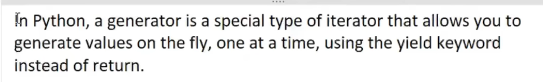

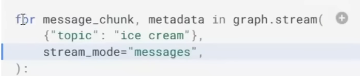

# SESSION 18 : Tools in LangGraph

https://youtu.be/_UuUigoM9MA?list=PLKnIA16_RmvYsvB8qkUQuJmJNuiCUJFPL

## Tool node in Langgraph : executes all the tools

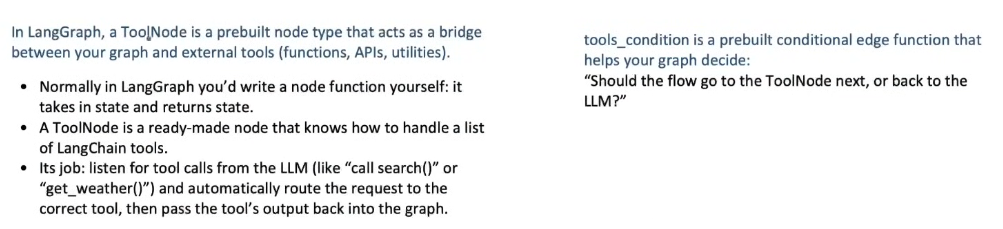


* **Tool Node** 🛠️
  A node that wraps a function or external tool (e.g., search API, calculator). When execution reaches this node, the tool is called.


* **Tool Conditions** 🔀
  Rules that decide **when** and **which tool node** should run. They act like “if–else” logic for routing between multiple tools.



👉 Think of it like:

* **Tool Node = the actual tool**


* **Tool Condition = the decision rule to pick the right tool**





### Example: Tool Node + Tool Conditions

```python
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

# Step 1: Define tools
def add_numbers(x: int, y: int) -> int:
    return x + y

def search_web(query: str) -> str:
    return f"Results for {query}"

# Step 2: Wrap them as Tool Nodes
calc_node = ToolNode(add_numbers)
search_node = ToolNode(search_web)

# Step 3: Define condition function (decides which tool to call)
def tool_condition(state):
    user_input = state["input"]
    if "add" in user_input.lower():
        return "calc"
    else:
        return "search"

# Step 4: Build the graph
workflow = StateGraph(dict)

workflow.add_node("calc", calc_node)
workflow.add_node("search", search_node)

workflow.add_edge(START, tool_condition)   # <-- condition decides path
workflow.add_edge("calc", END)
workflow.add_edge("search", END)

app = workflow.compile()

# Step 5: Run it
print(app.invoke({"input": "add 5 and 7"}))    # goes to calc
print(app.invoke({"input": "news about AI"}))  # goes to search
```

### 🔑 What’s Happening

* **Tool Nodes** → `calc_node` and `search_node`


* **Tool Condition** → `tool_condition` decides which one runs based on input

👉 Output will be:

```
{'output': 12}         # calculator used  
{'output': 'Results for news about AI'}  # search tool used  
```


